In [1]:
from pathlib import Path
import json
import matplotlib.pyplot as plt
import sys; sys.path.insert(0, '..')

from utils import parse_latencies, parse_power_log

In [2]:
DATA_PATH = Path('../../raw_data/power_profile_between_inference')
DELAY = 1 # delay introduced in seconds between inference cycles

In [3]:
with open((DATA_PATH/'idling_power.json'), 'r') as fp:
    data = json.load(fp)

avg_power = data['avg_idle_power']
print(f'Average power consumed in IDLE state: {avg_power}')

Average power consumed in IDLE state: 4176107.2315945667


## Alexnet

In this section, we will analyse the power consumption of Alexnet model. We will look at how the power is consumed for each inference cycle.

We add a delay between inference cycle to distinguish between consecutive inference cycles.


In [4]:
model_name = 'alexnet'

with open((DATA_PATH/model_name/f'{model_name}_power_log.log'), 'r') as fp:
    data = fp.readlines()
alexnet_power_data = parse_power_log(data)

with open((DATA_PATH/model_name/'trt_profiling/trt_layer_latency.json'), 'r') as fp:
    data = json.load(fp)
alexnet_latency_data = parse_latencies(data)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 24/24 [00:00<00:00, 61.07it/s]


In [5]:
print(f"Number of power entries for {model_name}: {len(alexnet_power_data)}")
print(f"Number of TensorRT layers in {model_name}: {len(alexnet_latency_data[0])}")
layer = list(data.keys())[0]
print(f"Number of latency entries for each layer: {len(alexnet_latency_data)}")

Number of power entries for alexnet: 2509736
Number of TensorRT layers in alexnet: 24
Number of latency entries for each layer: 3000


### Power Analysis

This is what the power plot looks like for 3000 inference cycles.

We see the power spikes in between 0.0 to 0.2 (1e6). This is where TorchTensorRT creates a TensorRT engine from PyTorch model. This part of the plot will be investigated as part of different notebook.

In this notebook, we will look at the plot after 0.2.

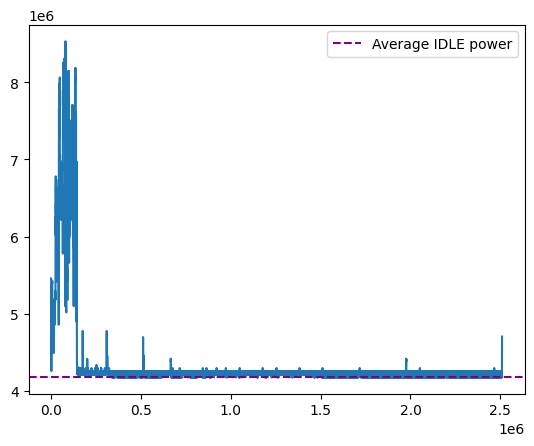

In [6]:
plt.plot([power for (timestamp, power) in alexnet_power_data])
plt.axhline(avg_power, color='purple', linestyle='--', label='Average IDLE power')
plt.legend()

In [7]:
from utils import plot_inference_cycle_power

### Observations

There is a lot to unpack here from all the plots below.

Before that we will talk about `plot_inference_cycle_power` function, how it works and what it is doing.
- For a input inference cycle, the function finds the start index in the power logs data where `power_log_time >= first_layer_start_time`
- We iterate this loop until `power_log_time <= last_layer_end_time + 1 (sec)`. The index where loop finishes includes the time taken for the inference (start of first layer to end of last layer) and the delay of 1 second.
- Similarly, we find a power index corresponding to end time of last layer.

We have 3 indexes in power data for a given inference cycle
1. When the first layer for the network started
2. When the last layer for the network ended
3. When the delay of 1 second ended after the inference

Using these 3 values, we plot a line plot showing these 3 points as vertical lines.

#### Result

Let's take a look at **first iteration**,
1. The start and end vertical lines for the inference are so close to each other.
2. The power when inference started and ended was `6259968.0`.
3. Then there is a delay of 1 second and power starts to decrease gradually.
4. The power at the end of 1 second delay was `4414080.0`

**Second iteration**
1. Similarly, the start and end vertical lines are overlapping.
2. The power seems to dissipating continuning the same trend from the first iteration.
3. The power at the start of inference was `4414080.0` and at the end of inference it decreased to `4454208.0`.
4. The power at the end of 1 second delay was `4253568.0`.


For rest of the iterations, the pattern looks like a downward step function where

- The power at inference start is a value greater than power consumed at IDLE state.
- The power at inference end is a value greater than power at inference start.
- The power at delay end is a value kess than both inference start and inference end `4213440.0`, the same power consumed for resnet18 and resnet34 models.


> **Alexnet model follows a similar power profile pattern to that of Resnet34 model.**



2025-01-17 10:32:24.511669 -> 2025-01-17 10:32:24.513866
2025-01-17 10:32:25.513866
Time taken by inference cycle 0: 0:00:00.002197
Iteration: 0, Power index: 142679 -> 142681
143468


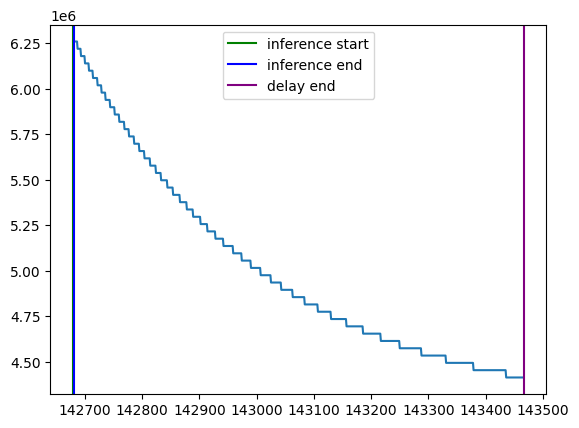

Power values:
Inference start: 6259968.0
Inference end: 6259968.0
Delay end: 4414080.0
----------------------------------------------------------------------------------------------------
2025-01-17 10:32:25.516082 -> 2025-01-17 10:32:25.518324
2025-01-17 10:32:26.518324
Time taken by inference cycle 1: 0:00:00.002242
Iteration: 1, Power index: 143468 -> 143471
144257


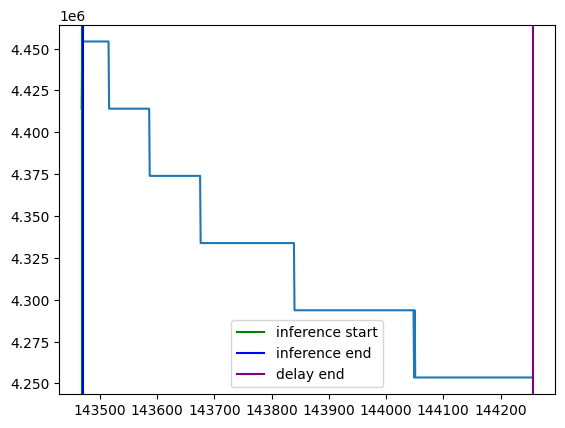

Power values:
Inference start: 4414080.0
Inference end: 4454208.0
Delay end: 4253568.0
----------------------------------------------------------------------------------------------------
2025-01-17 10:32:26.521018 -> 2025-01-17 10:32:26.523258
2025-01-17 10:32:27.523258
Time taken by inference cycle 2: 0:00:00.002240
Iteration: 2, Power index: 144258 -> 144261
145047


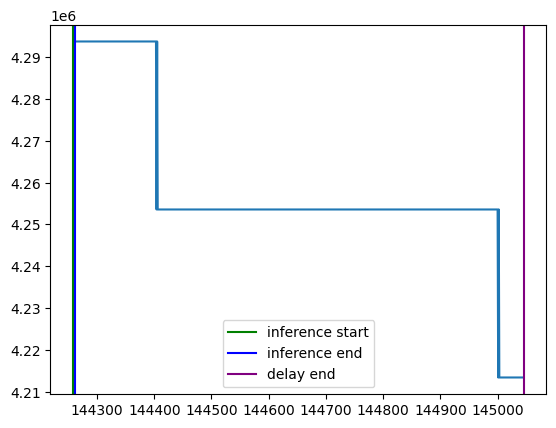

Power values:
Inference start: 4253568.0
Inference end: 4293696.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-17 10:32:27.525664 -> 2025-01-17 10:32:27.527912
2025-01-17 10:32:28.527912
Time taken by inference cycle 3: 0:00:00.002248
Iteration: 3, Power index: 145048 -> 145051
145837


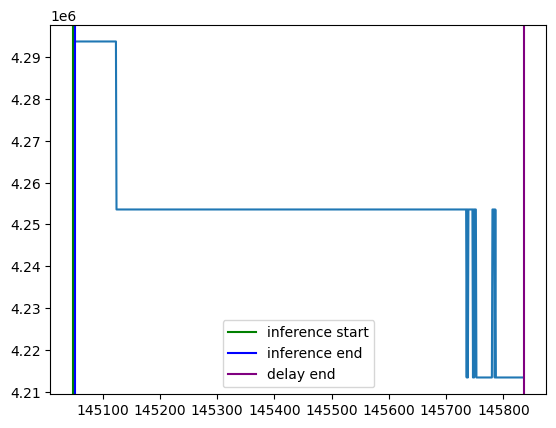

Power values:
Inference start: 4253568.0
Inference end: 4293696.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-17 10:32:28.530305 -> 2025-01-17 10:32:28.532549
2025-01-17 10:32:29.532549
Time taken by inference cycle 4: 0:00:00.002244
Iteration: 4, Power index: 145838 -> 145841
146628


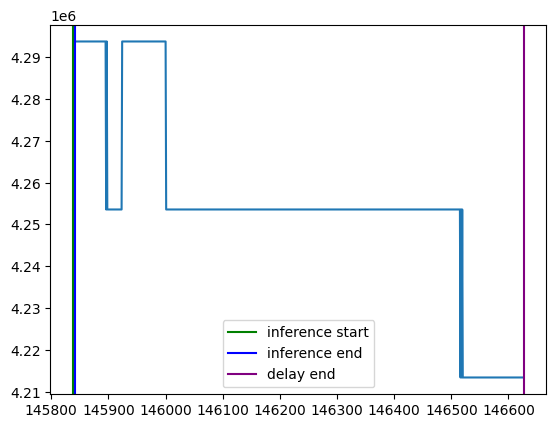

Power values:
Inference start: 4253568.0
Inference end: 4293696.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-17 10:32:29.534884 -> 2025-01-17 10:32:29.537146
2025-01-17 10:32:30.537146
Time taken by inference cycle 5: 0:00:00.002262
Iteration: 5, Power index: 146629 -> 146632
147419


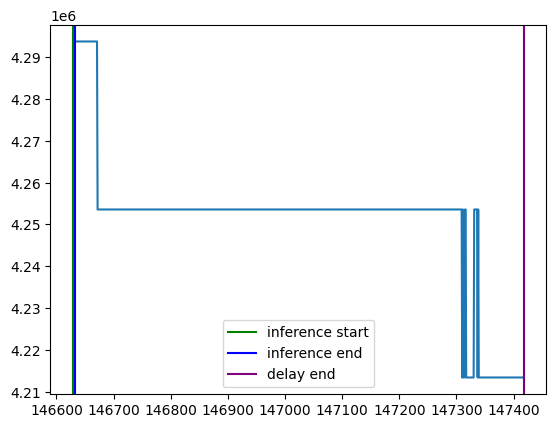

Power values:
Inference start: 4253568.0
Inference end: 4293696.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-17 10:32:30.539553 -> 2025-01-17 10:32:30.541802
2025-01-17 10:32:31.541802
Time taken by inference cycle 6: 0:00:00.002249
Iteration: 6, Power index: 147419 -> 147422
148207


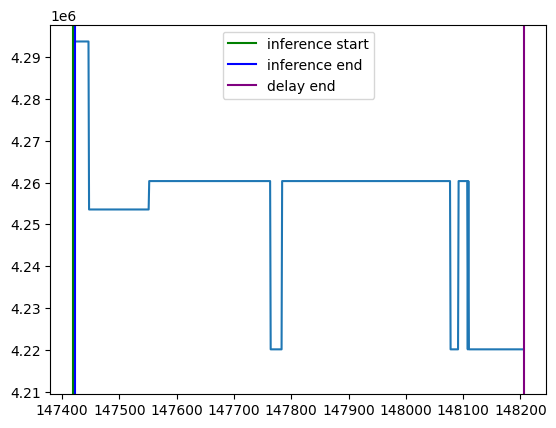

Power values:
Inference start: 4213440.0
Inference end: 4293696.0
Delay end: 4220160.0
----------------------------------------------------------------------------------------------------
2025-01-17 10:32:31.544284 -> 2025-01-17 10:32:31.546535
2025-01-17 10:32:32.546535
Time taken by inference cycle 7: 0:00:00.002251
Iteration: 7, Power index: 148208 -> 148211
148998


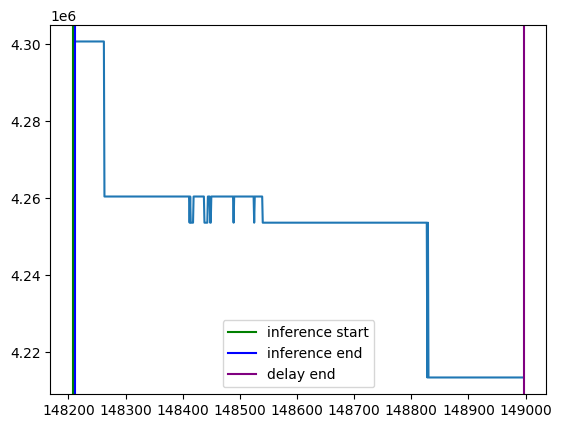

Power values:
Inference start: 4220160.0
Inference end: 4300544.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-17 10:32:32.548951 -> 2025-01-17 10:32:32.551214
2025-01-17 10:32:33.551214
Time taken by inference cycle 8: 0:00:00.002263
Iteration: 8, Power index: 148999 -> 149002
149788


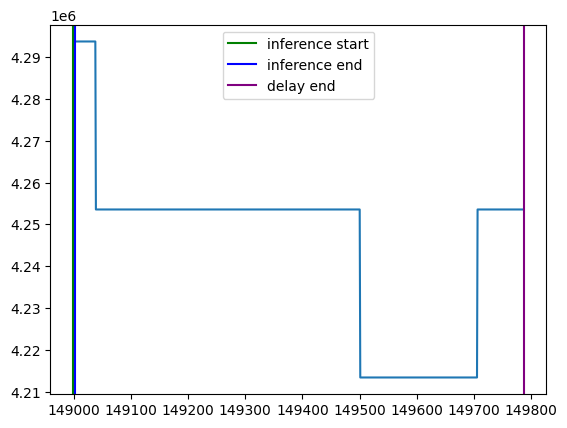

Power values:
Inference start: 4253568.0
Inference end: 4293696.0
Delay end: 4253568.0
----------------------------------------------------------------------------------------------------
2025-01-17 10:32:33.554361 -> 2025-01-17 10:32:33.556601
2025-01-17 10:32:34.556601
Time taken by inference cycle 9: 0:00:00.002240
Iteration: 9, Power index: 149790 -> 149792
150579


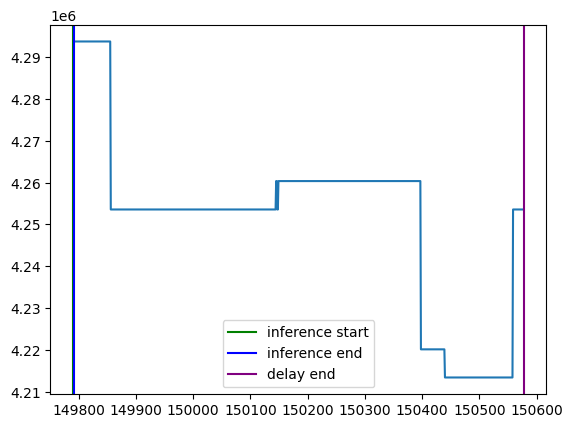

Power values:
Inference start: 4253568.0
Inference end: 4293696.0
Delay end: 4253568.0
----------------------------------------------------------------------------------------------------
2025-01-17 10:32:34.559132 -> 2025-01-17 10:32:34.561390
2025-01-17 10:32:35.561390
Time taken by inference cycle 10: 0:00:00.002258
Iteration: 10, Power index: 150580 -> 150582
151369


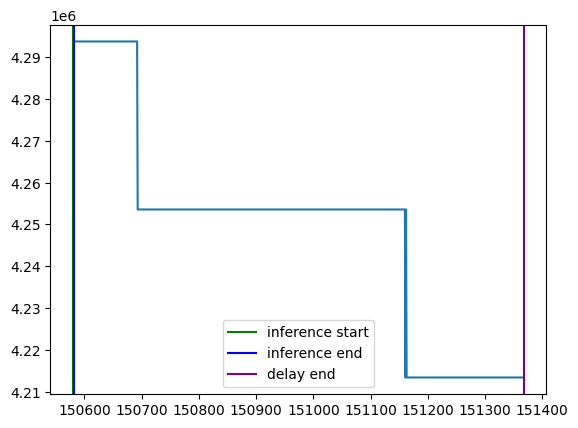

Power values:
Inference start: 4253568.0
Inference end: 4293696.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-17 10:32:35.563943 -> 2025-01-17 10:32:35.566192
2025-01-17 10:32:36.566192
Time taken by inference cycle 11: 0:00:00.002249
Iteration: 11, Power index: 151370 -> 151372
152159


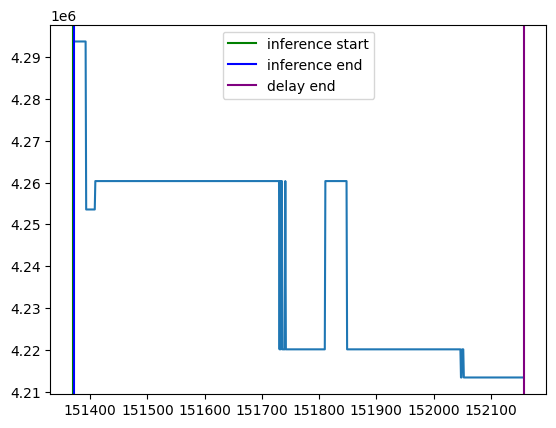

Power values:
Inference start: 4253568.0
Inference end: 4293696.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-17 10:32:36.568662 -> 2025-01-17 10:32:36.570914
2025-01-17 10:32:37.570914
Time taken by inference cycle 12: 0:00:00.002252
Iteration: 12, Power index: 152160 -> 152163
152949


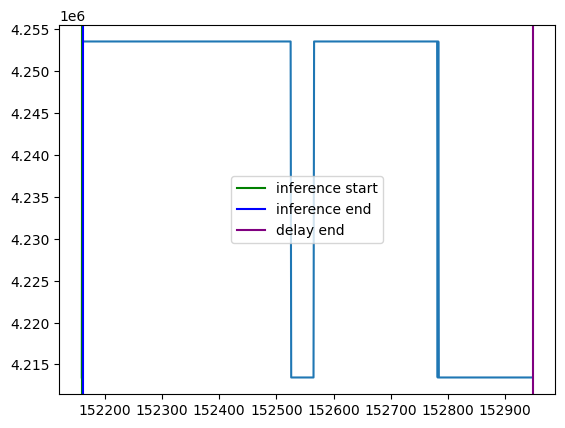

Power values:
Inference start: 4213440.0
Inference end: 4253568.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-17 10:32:37.573302 -> 2025-01-17 10:32:37.575550
2025-01-17 10:32:38.575550
Time taken by inference cycle 13: 0:00:00.002248
Iteration: 13, Power index: 152950 -> 152953
153739


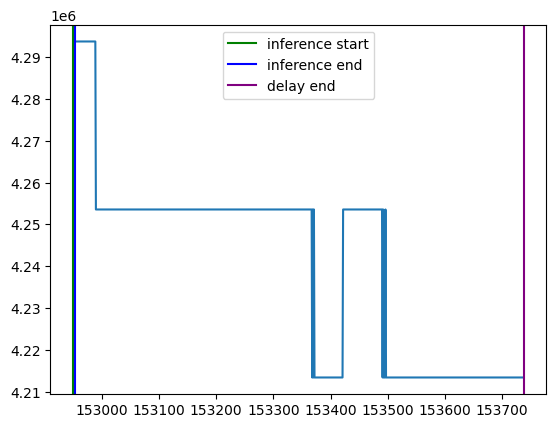

Power values:
Inference start: 4213440.0
Inference end: 4293696.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-17 10:32:38.577996 -> 2025-01-17 10:32:38.580238
2025-01-17 10:32:39.580238
Time taken by inference cycle 14: 0:00:00.002242
Iteration: 14, Power index: 153740 -> 153743
154530


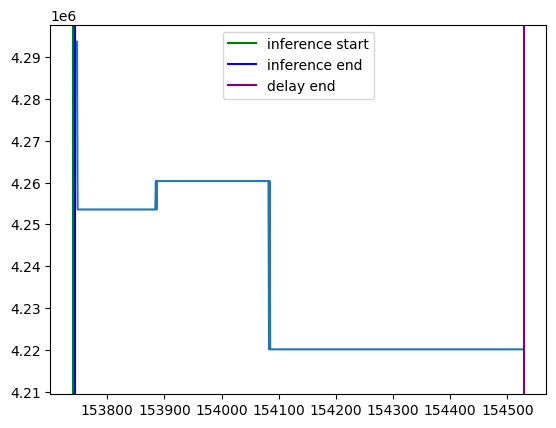

Power values:
Inference start: 4213440.0
Inference end: 4293696.0
Delay end: 4220160.0
----------------------------------------------------------------------------------------------------


In [8]:
for i in range(15):
    plot_inference_cycle_power(i, alexnet_power_data, alexnet_latency_data, DELAY)

2025-01-17 10:34:04.983441 -> 2025-01-17 10:34:04.985677
2025-01-17 10:34:05.985677
Time taken by inference cycle 100: 0:00:00.002236
Iteration: 100, Power index: 221643 -> 221646
222429


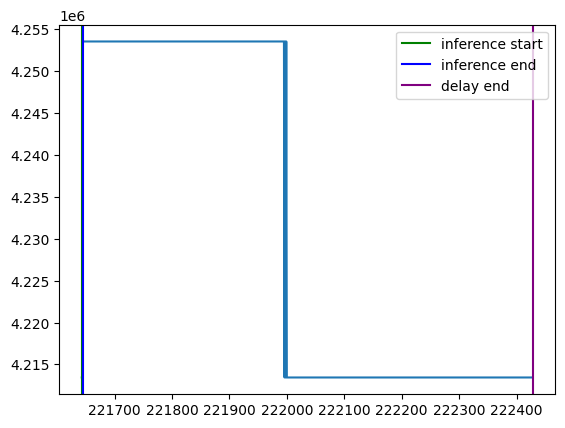

Power values:
Inference start: 4213440.0
Inference end: 4253568.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-17 10:34:05.988061 -> 2025-01-17 10:34:05.990305
2025-01-17 10:34:06.990305
Time taken by inference cycle 101: 0:00:00.002244
Iteration: 101, Power index: 222430 -> 222432
223215


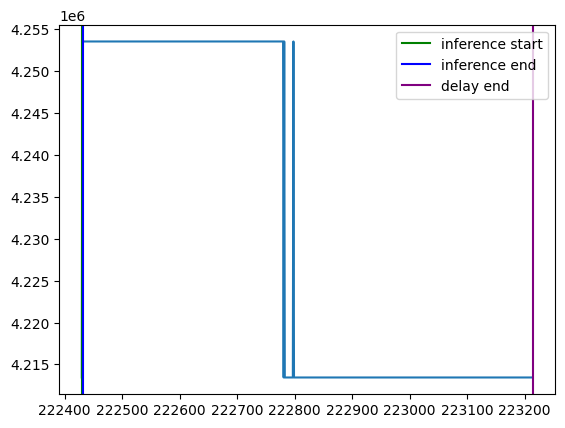

Power values:
Inference start: 4213440.0
Inference end: 4253568.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-17 10:34:06.992787 -> 2025-01-17 10:34:06.995019
2025-01-17 10:34:07.995019
Time taken by inference cycle 102: 0:00:00.002232
Iteration: 102, Power index: 223216 -> 223218
224001


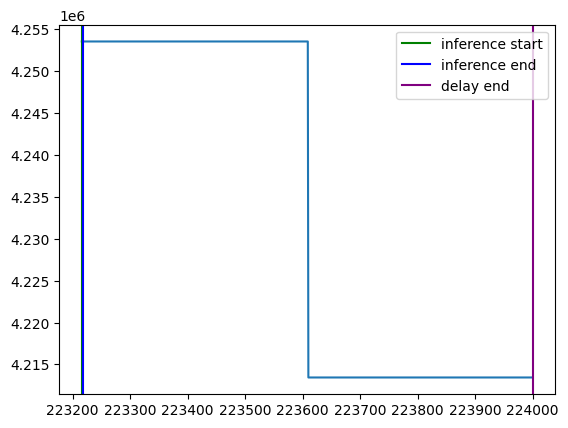

Power values:
Inference start: 4253568.0
Inference end: 4253568.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-17 10:34:07.997388 -> 2025-01-17 10:34:07.999630
2025-01-17 10:34:08.999630
Time taken by inference cycle 103: 0:00:00.002242
Iteration: 103, Power index: 224002 -> 224004
224786


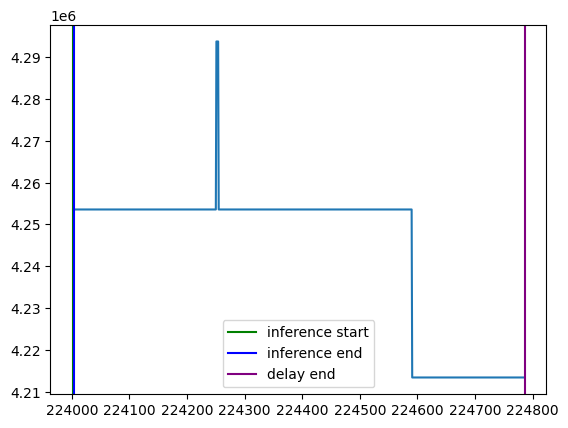

Power values:
Inference start: 4253568.0
Inference end: 4253568.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-17 10:34:09.002257 -> 2025-01-17 10:34:09.004497
2025-01-17 10:34:10.004497
Time taken by inference cycle 104: 0:00:00.002240
Iteration: 104, Power index: 224787 -> 224790
225572


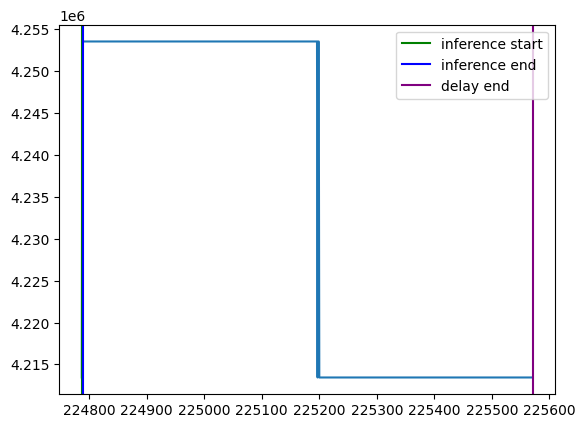

Power values:
Inference start: 4213440.0
Inference end: 4253568.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-17 10:34:10.006924 -> 2025-01-17 10:34:10.009174
2025-01-17 10:34:11.009174
Time taken by inference cycle 105: 0:00:00.002250
Iteration: 105, Power index: 225573 -> 225576
226358


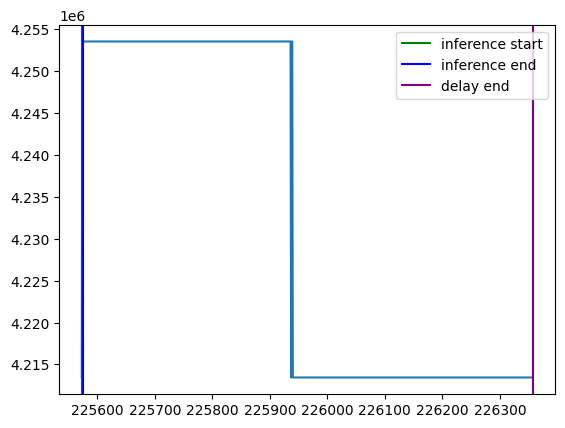

Power values:
Inference start: 4213440.0
Inference end: 4253568.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-17 10:34:11.011640 -> 2025-01-17 10:34:11.013881
2025-01-17 10:34:12.013881
Time taken by inference cycle 106: 0:00:00.002241
Iteration: 106, Power index: 226359 -> 226361
227144


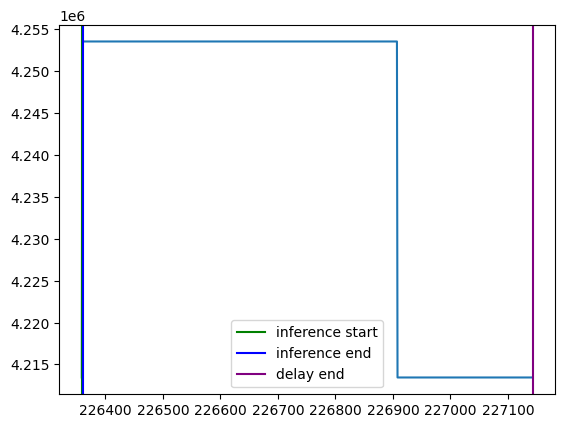

Power values:
Inference start: 4213440.0
Inference end: 4253568.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-17 10:34:12.016410 -> 2025-01-17 10:34:12.018684
2025-01-17 10:34:13.018684
Time taken by inference cycle 107: 0:00:00.002274
Iteration: 107, Power index: 227145 -> 227147
227930


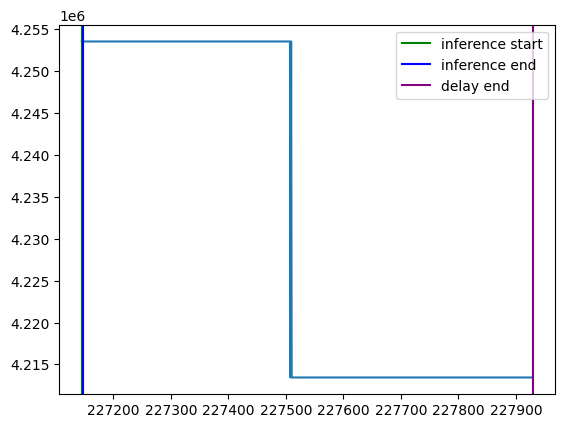

Power values:
Inference start: 4253568.0
Inference end: 4253568.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-17 10:34:13.021137 -> 2025-01-17 10:34:13.023390
2025-01-17 10:34:14.023390
Time taken by inference cycle 108: 0:00:00.002253
Iteration: 108, Power index: 227930 -> 227933
228715


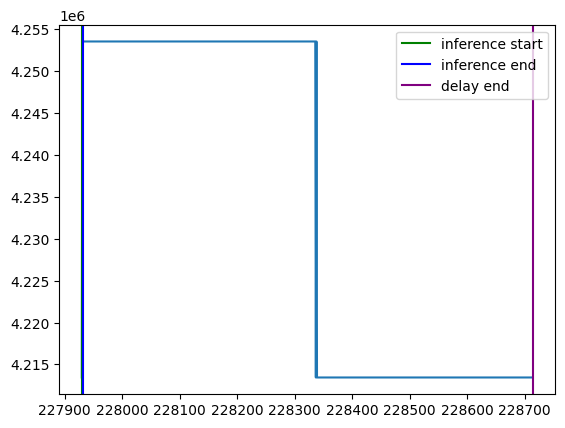

Power values:
Inference start: 4213440.0
Inference end: 4253568.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-17 10:34:14.025886 -> 2025-01-17 10:34:14.028128
2025-01-17 10:34:15.028128
Time taken by inference cycle 109: 0:00:00.002242
Iteration: 109, Power index: 228716 -> 228719
229501


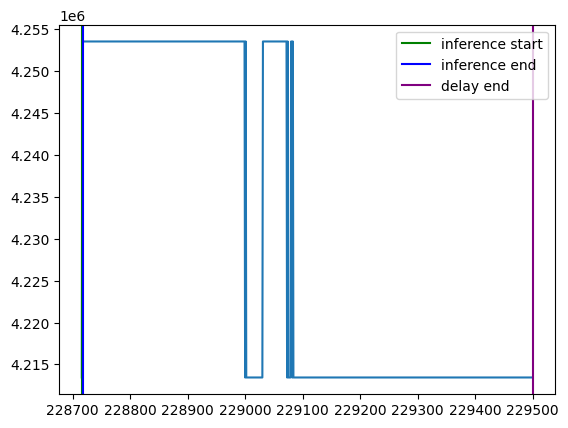

Power values:
Inference start: 4213440.0
Inference end: 4253568.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-17 10:34:15.030675 -> 2025-01-17 10:34:15.032871
2025-01-17 10:34:16.032871
Time taken by inference cycle 110: 0:00:00.002196
Iteration: 110, Power index: 229502 -> 229505
230287


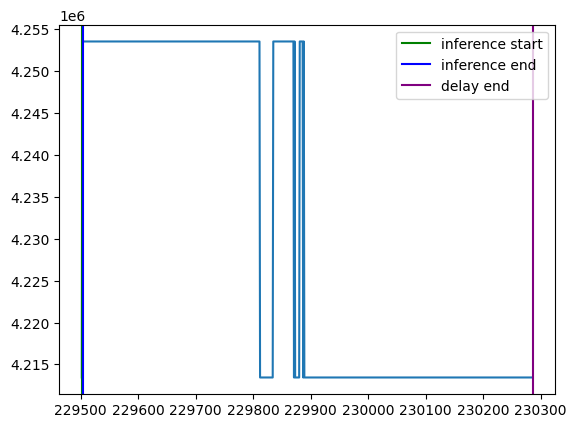

Power values:
Inference start: 4213440.0
Inference end: 4253568.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-17 10:34:16.035385 -> 2025-01-17 10:34:16.037618
2025-01-17 10:34:17.037618
Time taken by inference cycle 111: 0:00:00.002233
Iteration: 111, Power index: 230288 -> 230291
231073


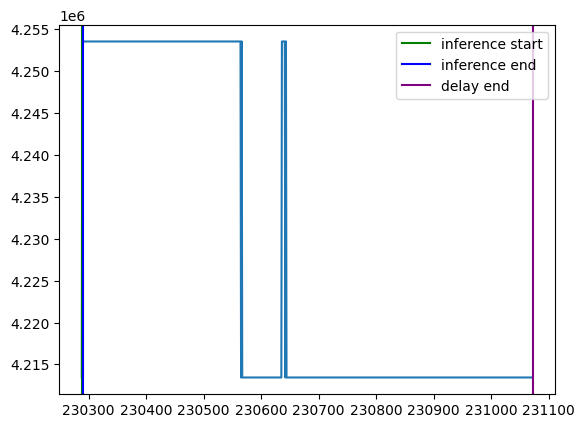

Power values:
Inference start: 4213440.0
Inference end: 4253568.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-17 10:34:17.040042 -> 2025-01-17 10:34:17.042274
2025-01-17 10:34:18.042274
Time taken by inference cycle 112: 0:00:00.002232
Iteration: 112, Power index: 231074 -> 231077
231859


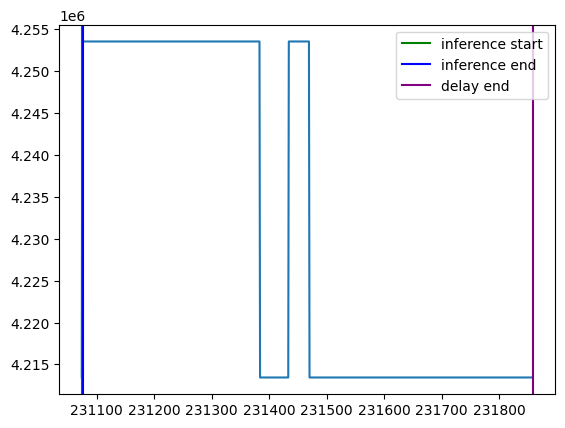

Power values:
Inference start: 4213440.0
Inference end: 4253568.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-17 10:34:18.044805 -> 2025-01-17 10:34:18.047043
2025-01-17 10:34:19.047043
Time taken by inference cycle 113: 0:00:00.002238
Iteration: 113, Power index: 231860 -> 231863
232645


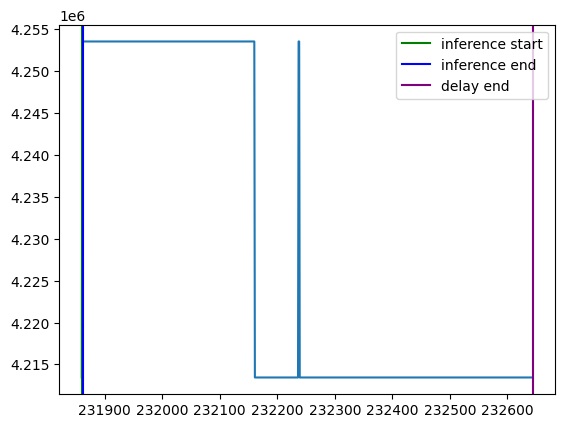

Power values:
Inference start: 4213440.0
Inference end: 4253568.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-17 10:34:19.049458 -> 2025-01-17 10:34:19.051692
2025-01-17 10:34:20.051692
Time taken by inference cycle 114: 0:00:00.002234
Iteration: 114, Power index: 232646 -> 232649
233431


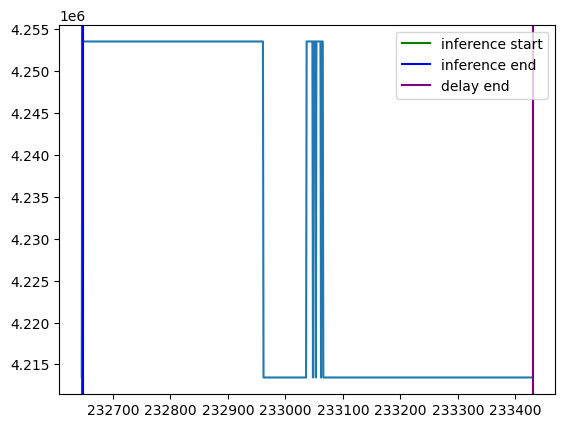

Power values:
Inference start: 4213440.0
Inference end: 4253568.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-17 10:34:20.054176 -> 2025-01-17 10:34:20.056413
2025-01-17 10:34:21.056413
Time taken by inference cycle 115: 0:00:00.002237
Iteration: 115, Power index: 233432 -> 233435
234217


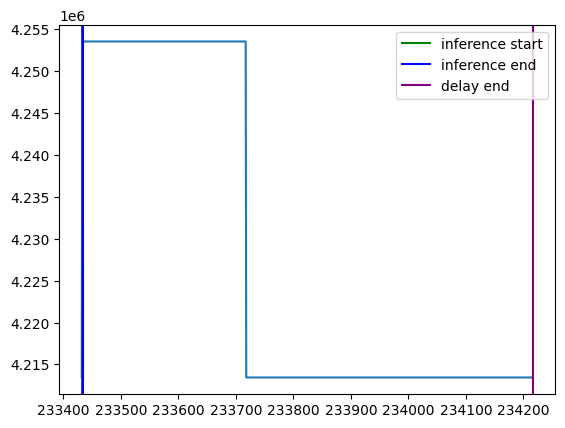

Power values:
Inference start: 4213440.0
Inference end: 4253568.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-17 10:34:21.058848 -> 2025-01-17 10:34:21.061114
2025-01-17 10:34:22.061114
Time taken by inference cycle 116: 0:00:00.002266
Iteration: 116, Power index: 234218 -> 234220
235003


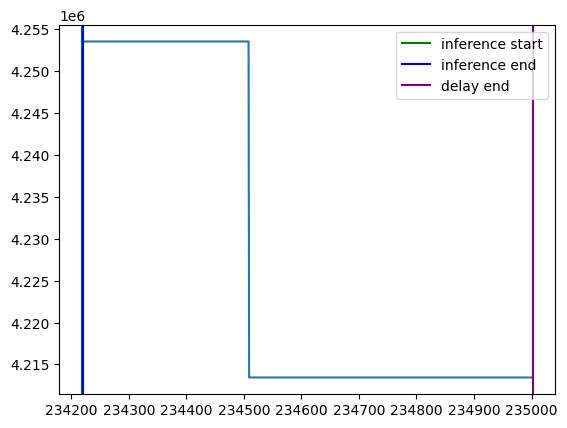

Power values:
Inference start: 4253568.0
Inference end: 4253568.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-17 10:34:22.063480 -> 2025-01-17 10:34:22.065727
2025-01-17 10:34:23.065727
Time taken by inference cycle 117: 0:00:00.002247
Iteration: 117, Power index: 235004 -> 235006
235788


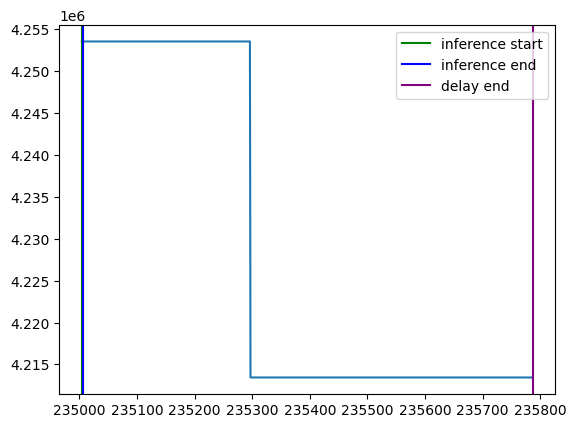

Power values:
Inference start: 4253568.0
Inference end: 4253568.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-17 10:34:23.068157 -> 2025-01-17 10:34:23.070391
2025-01-17 10:34:24.070391
Time taken by inference cycle 118: 0:00:00.002234
Iteration: 118, Power index: 235789 -> 235792
236574


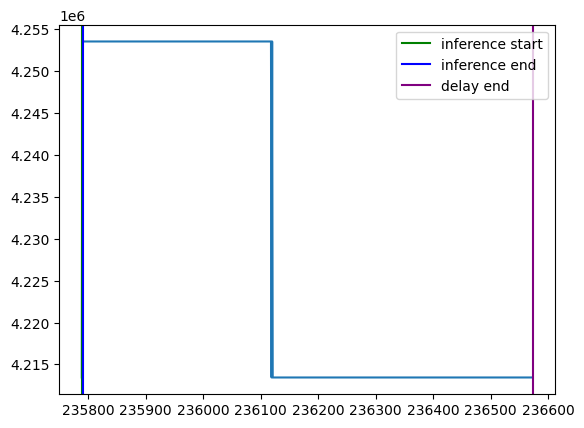

Power values:
Inference start: 4213440.0
Inference end: 4253568.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-17 10:34:24.072846 -> 2025-01-17 10:34:24.075082
2025-01-17 10:34:25.075082
Time taken by inference cycle 119: 0:00:00.002236
Iteration: 119, Power index: 236575 -> 236578
237360


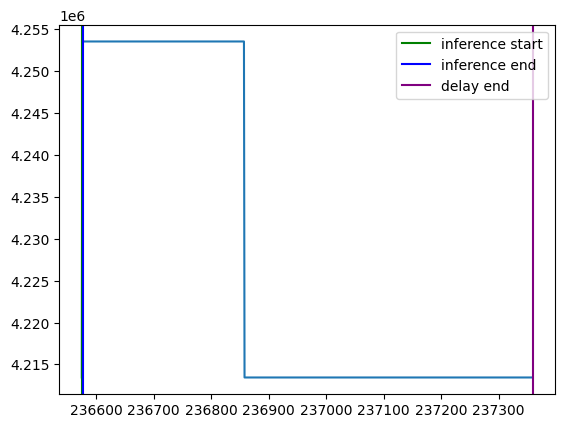

Power values:
Inference start: 4213440.0
Inference end: 4253568.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-17 10:34:25.077516 -> 2025-01-17 10:34:25.079754
2025-01-17 10:34:26.079754
Time taken by inference cycle 120: 0:00:00.002238
Iteration: 120, Power index: 237361 -> 237364
238145


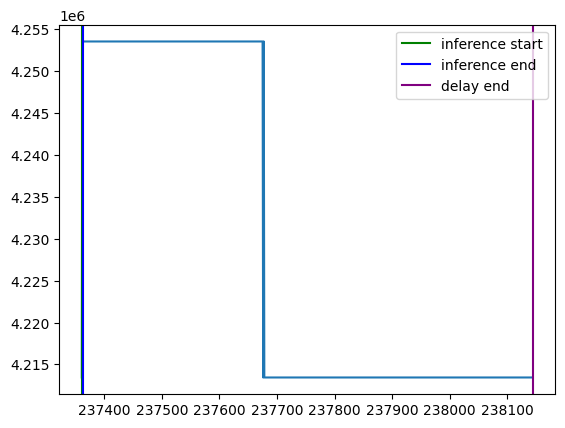

Power values:
Inference start: 4213440.0
Inference end: 4253568.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-17 10:34:26.082381 -> 2025-01-17 10:34:26.084612
2025-01-17 10:34:27.084612
Time taken by inference cycle 121: 0:00:00.002231
Iteration: 121, Power index: 238146 -> 238149
238932


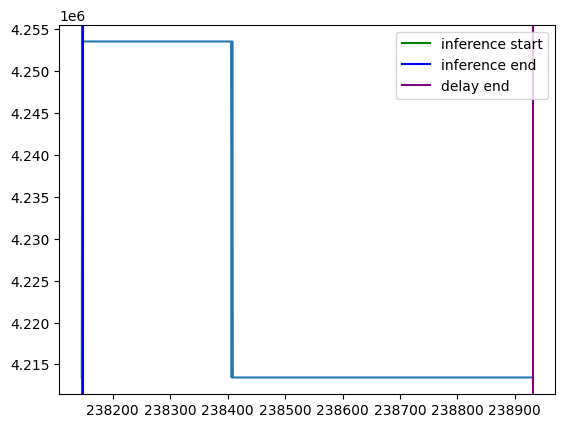

Power values:
Inference start: 4213440.0
Inference end: 4253568.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-17 10:34:27.087141 -> 2025-01-17 10:34:27.089377
2025-01-17 10:34:28.089377
Time taken by inference cycle 122: 0:00:00.002236
Iteration: 122, Power index: 238933 -> 238936
239719


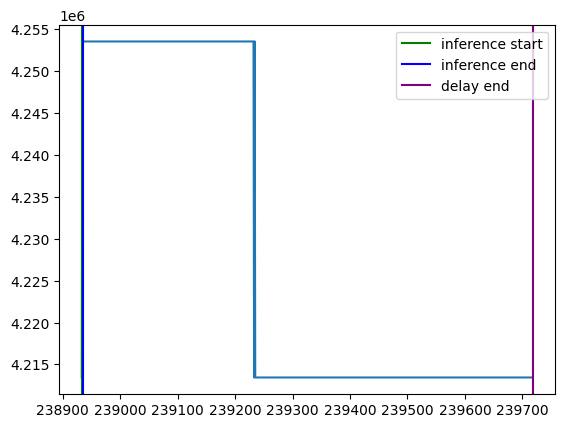

Power values:
Inference start: 4213440.0
Inference end: 4253568.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-17 10:34:28.091867 -> 2025-01-17 10:34:28.094102
2025-01-17 10:34:29.094102
Time taken by inference cycle 123: 0:00:00.002235
Iteration: 123, Power index: 239720 -> 239723
240506


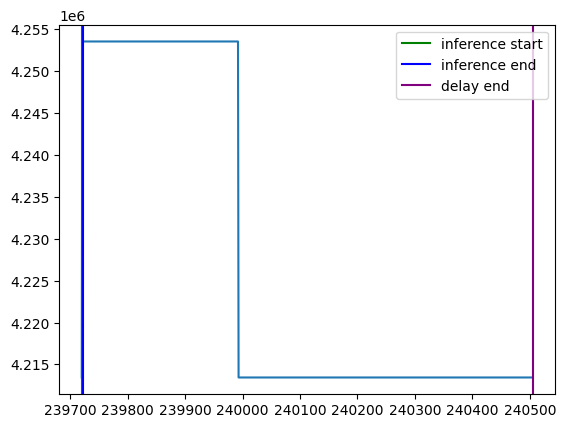

Power values:
Inference start: 4213440.0
Inference end: 4253568.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-17 10:34:29.095919 -> 2025-01-17 10:34:29.098160
2025-01-17 10:34:30.098160
Time taken by inference cycle 124: 0:00:00.002241
Iteration: 124, Power index: 240506 -> 240509
241292


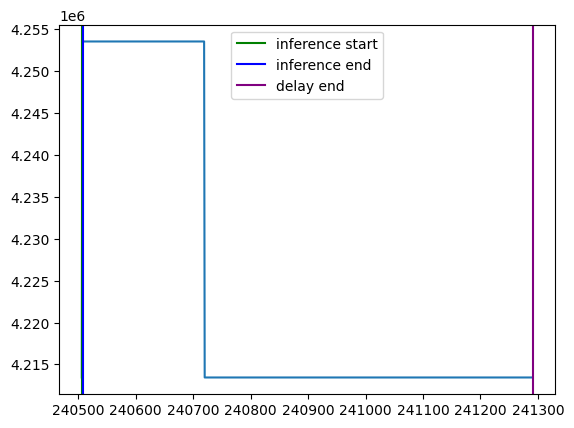

Power values:
Inference start: 4213440.0
Inference end: 4253568.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-17 10:34:30.099927 -> 2025-01-17 10:34:30.102164
2025-01-17 10:34:31.102164
Time taken by inference cycle 125: 0:00:00.002237
Iteration: 125, Power index: 241292 -> 241295
242079


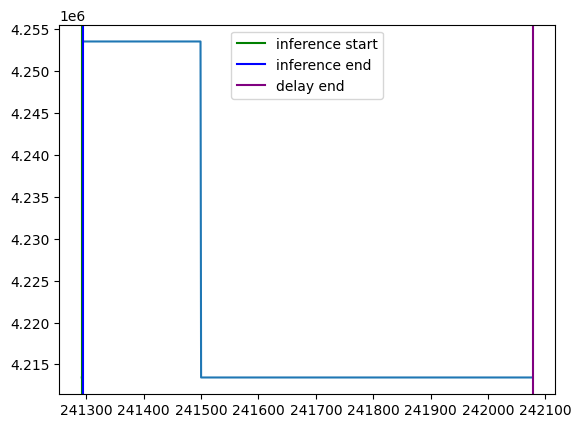

Power values:
Inference start: 4213440.0
Inference end: 4253568.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-17 10:34:31.104533 -> 2025-01-17 10:34:31.106790
2025-01-17 10:34:32.106790
Time taken by inference cycle 126: 0:00:00.002257
Iteration: 126, Power index: 242080 -> 242082
242866


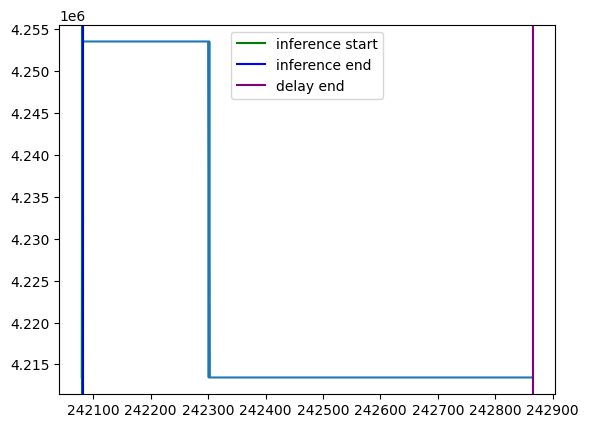

Power values:
Inference start: 4213440.0
Inference end: 4253568.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-17 10:34:32.109276 -> 2025-01-17 10:34:32.111495
2025-01-17 10:34:33.111495
Time taken by inference cycle 127: 0:00:00.002219
Iteration: 127, Power index: 242867 -> 242869
243652


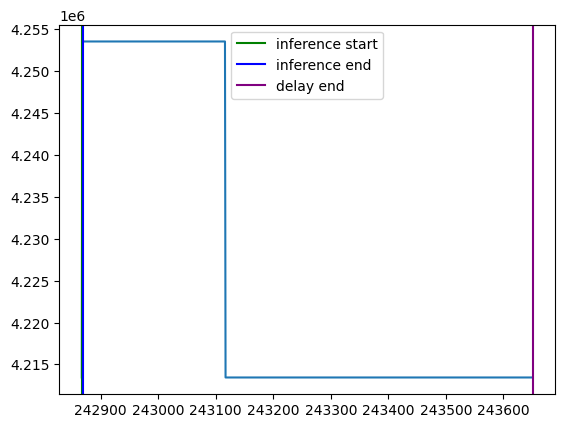

Power values:
Inference start: 4213440.0
Inference end: 4253568.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-17 10:34:33.113955 -> 2025-01-17 10:34:33.116189
2025-01-17 10:34:34.116189
Time taken by inference cycle 128: 0:00:00.002234
Iteration: 128, Power index: 243653 -> 243656
244437


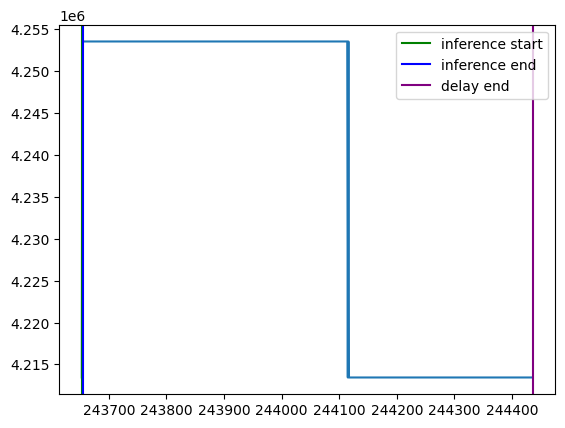

Power values:
Inference start: 4213440.0
Inference end: 4253568.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-17 10:34:34.119551 -> 2025-01-17 10:34:34.121913
2025-01-17 10:34:35.121913
Time taken by inference cycle 129: 0:00:00.002362
Iteration: 129, Power index: 244439 -> 244442
245225


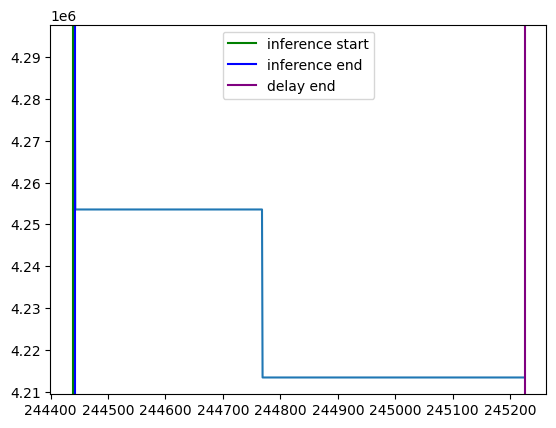

Power values:
Inference start: 4253568.0
Inference end: 4293696.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-17 10:34:35.124531 -> 2025-01-17 10:34:35.126896
2025-01-17 10:34:36.126896
Time taken by inference cycle 130: 0:00:00.002365
Iteration: 130, Power index: 245226 -> 245229
246012


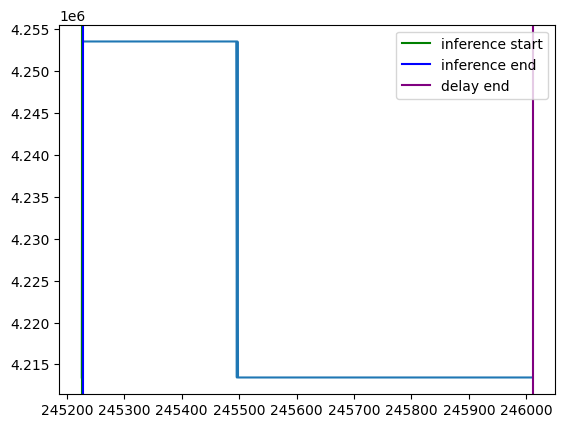

Power values:
Inference start: 4213440.0
Inference end: 4253568.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-17 10:34:36.129443 -> 2025-01-17 10:34:36.131682
2025-01-17 10:34:37.131682
Time taken by inference cycle 131: 0:00:00.002239
Iteration: 131, Power index: 246013 -> 246016
246799


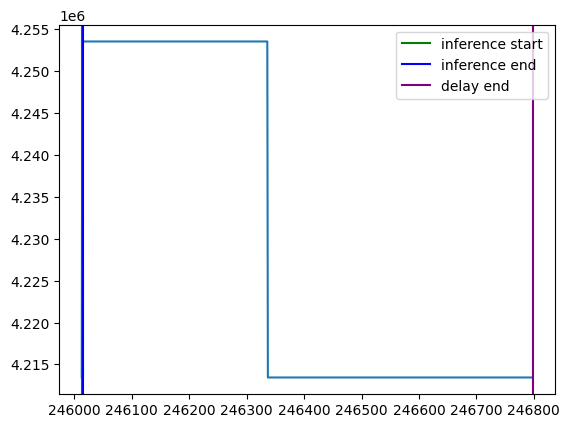

Power values:
Inference start: 4213440.0
Inference end: 4253568.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-17 10:34:37.134188 -> 2025-01-17 10:34:37.136409
2025-01-17 10:34:38.136409
Time taken by inference cycle 132: 0:00:00.002221
Iteration: 132, Power index: 246800 -> 246803
247585


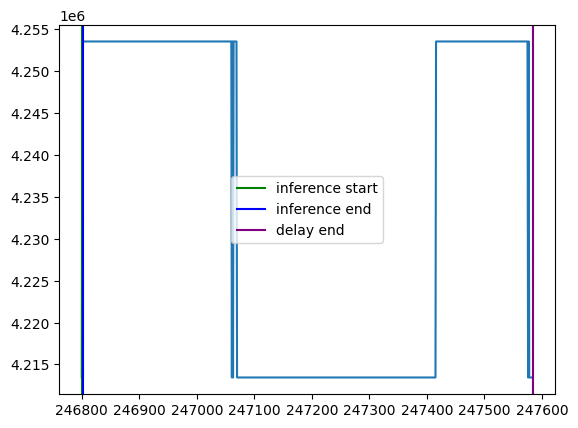

Power values:
Inference start: 4213440.0
Inference end: 4253568.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-17 10:34:38.139222 -> 2025-01-17 10:34:38.141454
2025-01-17 10:34:39.141454
Time taken by inference cycle 133: 0:00:00.002232
Iteration: 133, Power index: 247586 -> 247589
248372


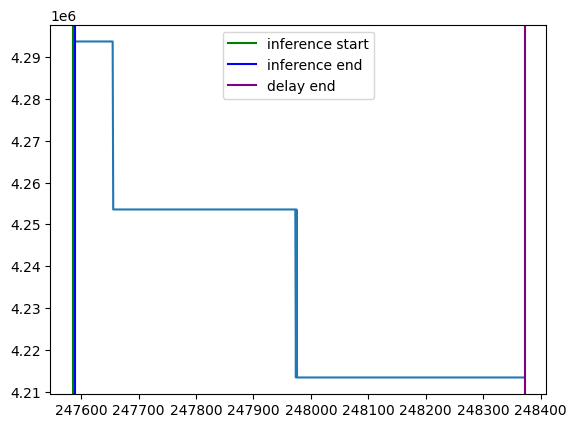

Power values:
Inference start: 4253568.0
Inference end: 4293696.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-17 10:34:39.143892 -> 2025-01-17 10:34:39.146147
2025-01-17 10:34:40.146147
Time taken by inference cycle 134: 0:00:00.002255
Iteration: 134, Power index: 248373 -> 248376
249158


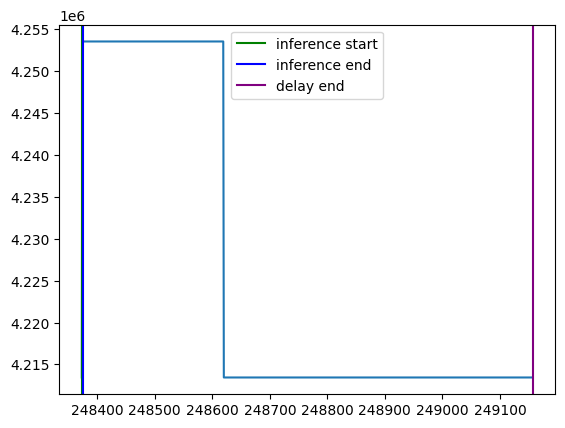

Power values:
Inference start: 4213440.0
Inference end: 4253568.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-17 10:34:40.148695 -> 2025-01-17 10:34:40.150937
2025-01-17 10:34:41.150937
Time taken by inference cycle 135: 0:00:00.002242
Iteration: 135, Power index: 249159 -> 249162
249945


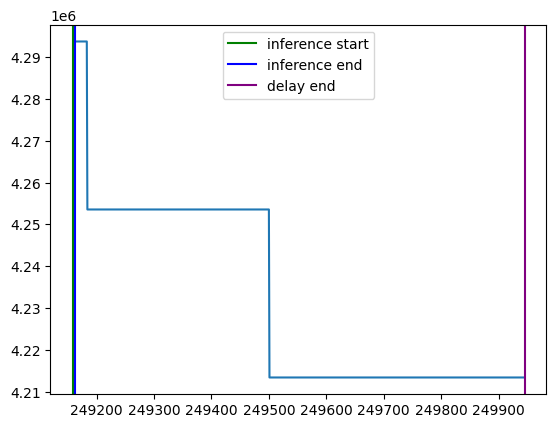

Power values:
Inference start: 4213440.0
Inference end: 4293696.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-17 10:34:41.153337 -> 2025-01-17 10:34:41.155579
2025-01-17 10:34:42.155579
Time taken by inference cycle 136: 0:00:00.002242
Iteration: 136, Power index: 249946 -> 249948
250731


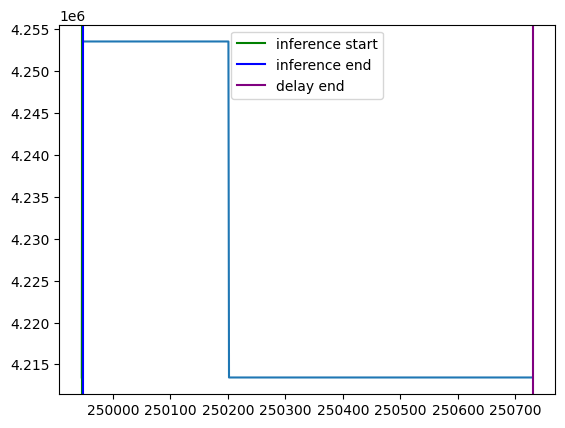

Power values:
Inference start: 4213440.0
Inference end: 4253568.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-17 10:34:42.158002 -> 2025-01-17 10:34:42.160241
2025-01-17 10:34:43.160241
Time taken by inference cycle 137: 0:00:00.002239
Iteration: 137, Power index: 250732 -> 250734
251517


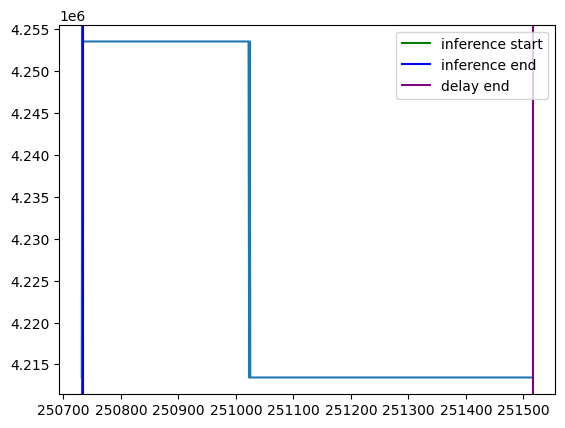

Power values:
Inference start: 4213440.0
Inference end: 4253568.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-17 10:34:43.162655 -> 2025-01-17 10:34:43.164849
2025-01-17 10:34:44.164849
Time taken by inference cycle 138: 0:00:00.002194
Iteration: 138, Power index: 251518 -> 251521
252303


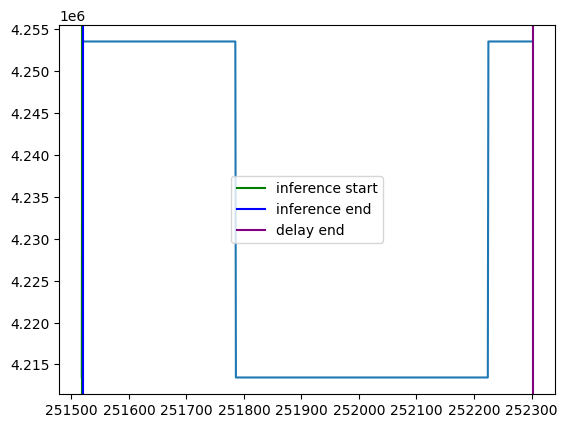

Power values:
Inference start: 4213440.0
Inference end: 4253568.0
Delay end: 4253568.0
----------------------------------------------------------------------------------------------------
2025-01-17 10:34:44.167643 -> 2025-01-17 10:34:44.169876
2025-01-17 10:34:45.169876
Time taken by inference cycle 139: 0:00:00.002233
Iteration: 139, Power index: 252305 -> 252307
253090


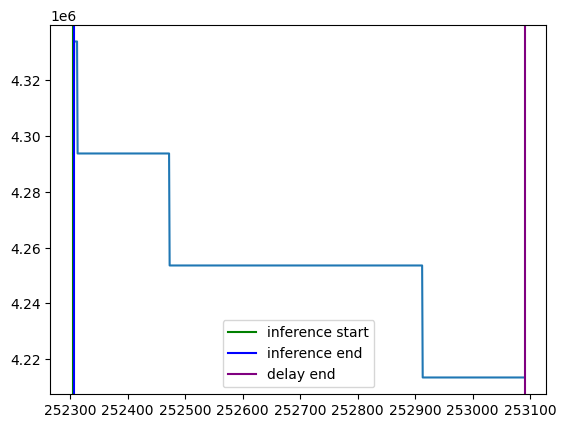

Power values:
Inference start: 4293696.0
Inference end: 4333824.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-17 10:34:45.172189 -> 2025-01-17 10:34:45.174423
2025-01-17 10:34:46.174423
Time taken by inference cycle 140: 0:00:00.002234
Iteration: 140, Power index: 253091 -> 253094
253876


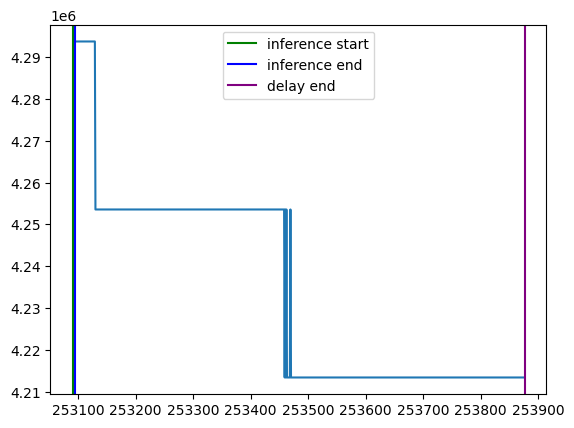

Power values:
Inference start: 4213440.0
Inference end: 4293696.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-17 10:34:46.176991 -> 2025-01-17 10:34:46.179239
2025-01-17 10:34:47.179239
Time taken by inference cycle 141: 0:00:00.002248
Iteration: 141, Power index: 253877 -> 253880
254663


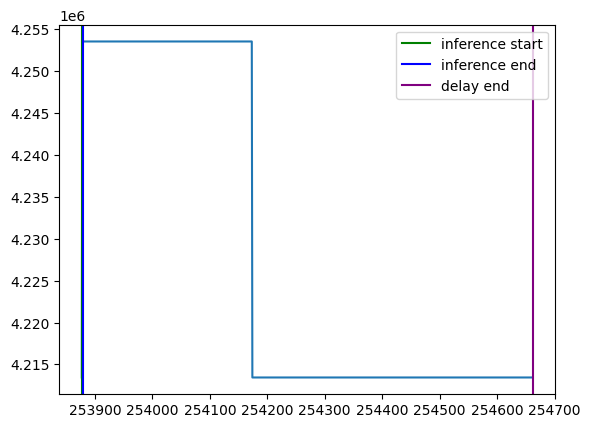

Power values:
Inference start: 4213440.0
Inference end: 4253568.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-17 10:34:47.181664 -> 2025-01-17 10:34:47.183907
2025-01-17 10:34:48.183907
Time taken by inference cycle 142: 0:00:00.002243
Iteration: 142, Power index: 254664 -> 254667
255449


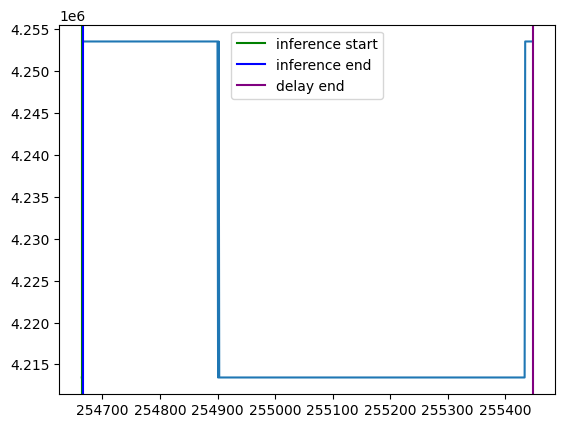

Power values:
Inference start: 4213440.0
Inference end: 4253568.0
Delay end: 4253568.0
----------------------------------------------------------------------------------------------------
2025-01-17 10:34:48.186782 -> 2025-01-17 10:34:48.188975
2025-01-17 10:34:49.188975
Time taken by inference cycle 143: 0:00:00.002193
Iteration: 143, Power index: 255450 -> 255453
256236


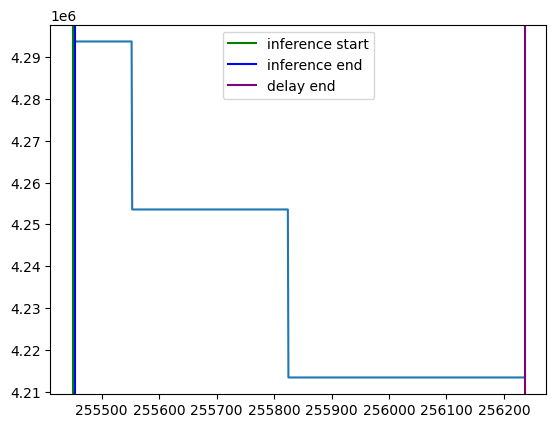

Power values:
Inference start: 4253568.0
Inference end: 4293696.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-17 10:34:49.191486 -> 2025-01-17 10:34:49.193744
2025-01-17 10:34:50.193744
Time taken by inference cycle 144: 0:00:00.002258
Iteration: 144, Power index: 256237 -> 256240
257021


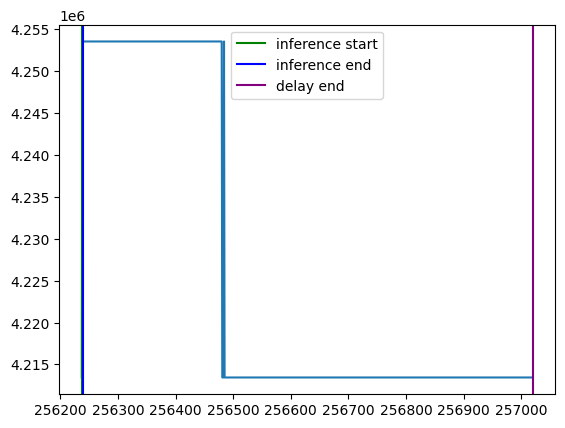

Power values:
Inference start: 4213440.0
Inference end: 4253568.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-17 10:34:50.196143 -> 2025-01-17 10:34:50.198374
2025-01-17 10:34:51.198374
Time taken by inference cycle 145: 0:00:00.002231
Iteration: 145, Power index: 257022 -> 257025
257808


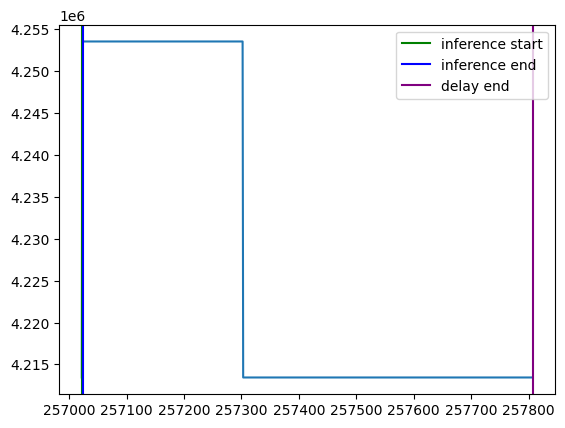

Power values:
Inference start: 4213440.0
Inference end: 4253568.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-17 10:34:51.199956 -> 2025-01-17 10:34:51.202193
2025-01-17 10:34:52.202193
Time taken by inference cycle 146: 0:00:00.002237
Iteration: 146, Power index: 257808 -> 257811
258594


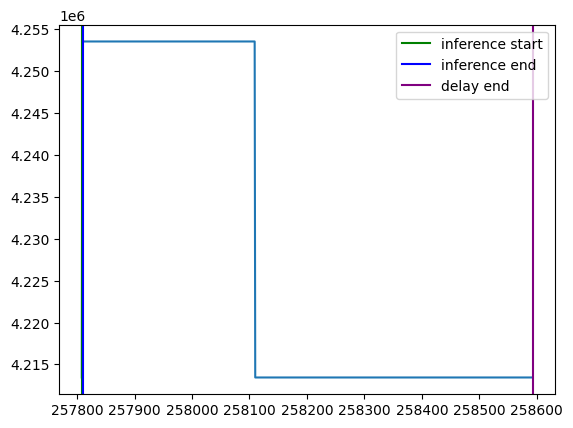

Power values:
Inference start: 4213440.0
Inference end: 4253568.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-17 10:34:52.203940 -> 2025-01-17 10:34:52.206172
2025-01-17 10:34:53.206172
Time taken by inference cycle 147: 0:00:00.002232
Iteration: 147, Power index: 258594 -> 258597
259379


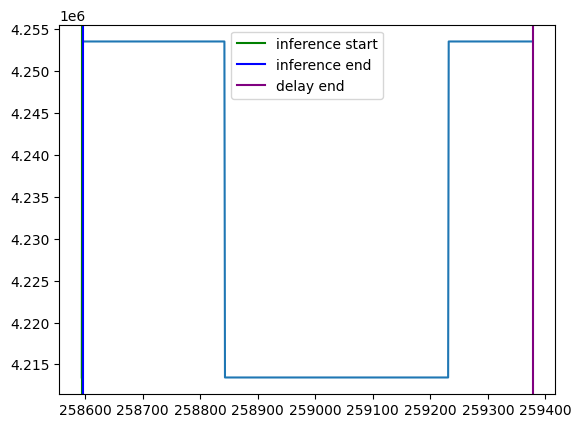

Power values:
Inference start: 4213440.0
Inference end: 4253568.0
Delay end: 4253568.0
----------------------------------------------------------------------------------------------------
2025-01-17 10:34:53.208516 -> 2025-01-17 10:34:53.210714
2025-01-17 10:34:54.210714
Time taken by inference cycle 148: 0:00:00.002198
Iteration: 148, Power index: 259380 -> 259382
260165


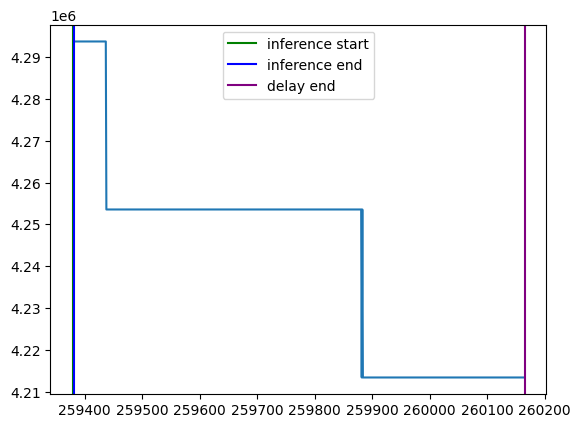

Power values:
Inference start: 4253568.0
Inference end: 4293696.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------
2025-01-17 10:34:54.213418 -> 2025-01-17 10:34:54.215661
2025-01-17 10:34:55.215661
Time taken by inference cycle 149: 0:00:00.002243
Iteration: 149, Power index: 260166 -> 260169
260952


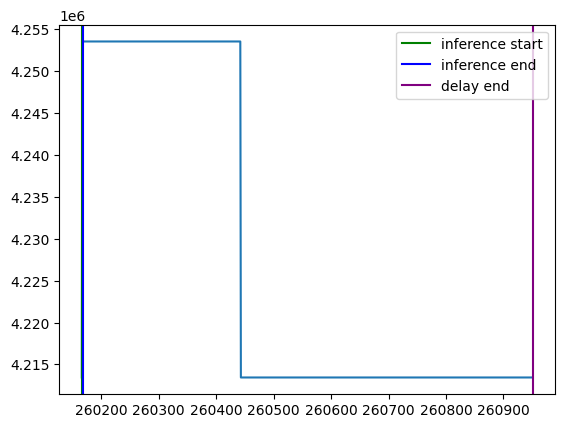

Power values:
Inference start: 4213440.0
Inference end: 4253568.0
Delay end: 4213440.0
----------------------------------------------------------------------------------------------------


In [13]:
for i in range(100, 150):
    plot_inference_cycle_power(i, alexnet_power_data, alexnet_latency_data, DELAY)

## Conclusion

Number of TensorRT layers: 24

Most common power profile

```
Inference start: 4213440.0
Inference end: 4253568.0
Delay end: 4213440.0
```